In [0]:
# =========================================================
# Análise: Vantagem do mando de campo por clube
# Métricas:
# 1) Saldo absoluto de vitórias (robusta ao volume)
# 2) Ranking híbrido: Saldo de vitórias + Diferença de PPG
# =========================================================

import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Consulta SQL
# ---------------------------------------------------------
query = """
WITH resultados_clube AS (
    SELECT
        mandante AS clube,
        'Mandante' AS mando,
        COUNT(*) AS jogos,
        SUM(CASE WHEN mandante_placar > visitante_placar THEN 1 ELSE 0 END) AS vitorias,
        SUM(CASE WHEN mandante_placar = visitante_placar THEN 1 ELSE 0 END) AS empates
    FROM fato_partida
    GROUP BY mandante

    UNION ALL

    SELECT
        visitante AS clube,
        'Visitante' AS mando,
        COUNT(*) AS jogos,
        SUM(CASE WHEN visitante_placar > mandante_placar THEN 1 ELSE 0 END) AS vitorias,
        SUM(CASE WHEN visitante_placar = mandante_placar THEN 1 ELSE 0 END) AS empates
    FROM fato_partida
    GROUP BY visitante
),

pivot_clube AS (
    SELECT
        clube,
        SUM(CASE WHEN mando = 'Mandante' THEN jogos END) AS jogos_mandante,
        SUM(CASE WHEN mando = 'Visitante' THEN jogos END) AS jogos_visitante,
        SUM(CASE WHEN mando = 'Mandante' THEN vitorias END) AS vitorias_mandante,
        SUM(CASE WHEN mando = 'Visitante' THEN vitorias END) AS vitorias_visitante,
        SUM(CASE WHEN mando = 'Mandante' THEN empates END) AS empates_mandante,
        SUM(CASE WHEN mando = 'Visitante' THEN empates END) AS empates_visitante
    FROM resultados_clube
    GROUP BY clube
),

metricas AS (
    SELECT
        clube,
        jogos_mandante,
        jogos_visitante,
        vitorias_mandante,
        vitorias_visitante,
        (vitorias_mandante - vitorias_visitante) AS saldo_vitorias_mando,

        ROUND(
            (3 * vitorias_mandante + empates_mandante) / CAST(jogos_mandante AS DOUBLE),
            3
        ) AS ppg_mandante,

        ROUND(
            (3 * vitorias_visitante + empates_visitante) / CAST(jogos_visitante AS DOUBLE),
            3
        ) AS ppg_visitante
    FROM pivot_clube
)

SELECT
    clube,
    jogos_mandante,
    jogos_visitante,
    vitorias_mandante,
    vitorias_visitante,
    saldo_vitorias_mando,
    ppg_mandante,
    ppg_visitante,
    ROUND(ppg_mandante - ppg_visitante, 3) AS vantagem_ppg
FROM metricas
ORDER BY saldo_vitorias_mando DESC
"""

# Executa a consulta
df_resultado = spark.sql(query)

# Exibe tabela final (fica salva no .ipynb)
display(df_resultado)

clube,jogos_mandante,jogos_visitante,vitorias_mandante,vitorias_visitante,saldo_vitorias_mando,ppg_mandante,ppg_visitante,vantagem_ppg
Athletico-pr,390,390,221,88,133,1.962,0.9,1.062
Gremio,369,369,218,98,120,2.003,1.068,0.935
Santos,409,409,230,110,120,1.946,1.078,0.868
Internacional,390,390,229,110,119,2.0,1.126,0.874
Atletico-mg,390,389,218,109,109,1.89,1.139,0.751
Sao Paulo,409,409,234,131,103,1.988,1.249,0.739
Corinthians,390,390,211,115,96,1.903,1.192,0.711
Palmeiras,367,367,212,117,95,1.948,1.259,0.689
Flamengo,408,410,224,130,94,1.902,1.237,0.665
Coritiba,295,295,140,49,91,1.671,0.763,0.908


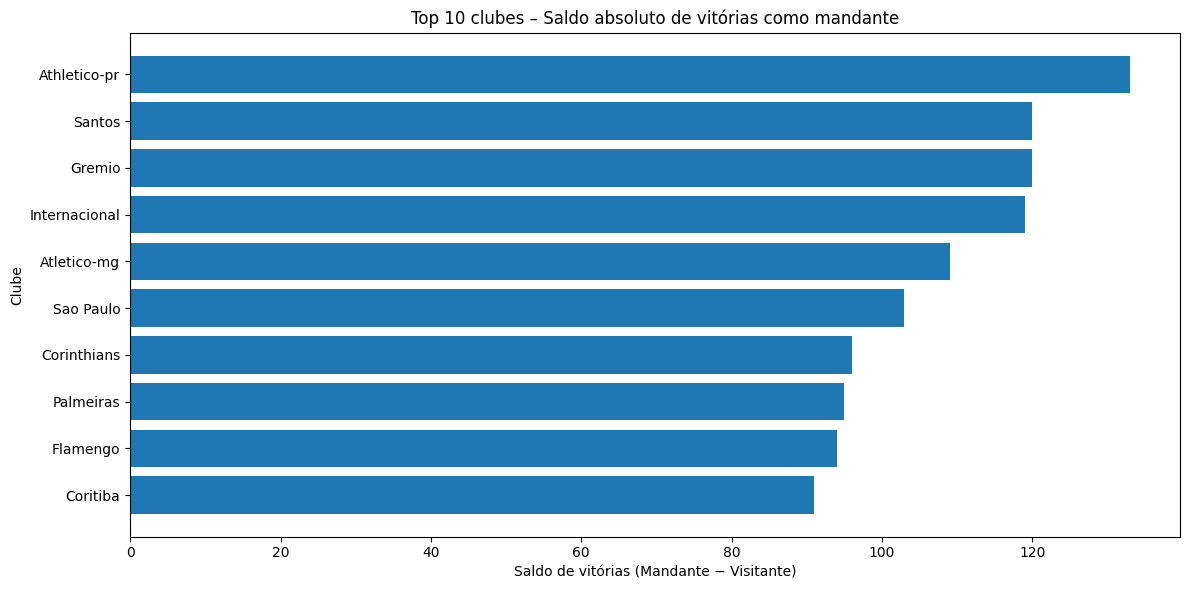

In [0]:
# =========================================================
# GRÁFICO 1 — Saldo absoluto de vitórias como mandante
# =========================================================

pdf_saldo = df_resultado.limit(10).toPandas()

plt.figure(figsize=(12, 6))
plt.barh(
    pdf_saldo["clube"],
    pdf_saldo["saldo_vitorias_mando"]
)
plt.xlabel("Saldo de vitórias (Mandante − Visitante)")
plt.ylabel("Clube")
plt.title("Top 10 clubes – Saldo absoluto de vitórias como mandante")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

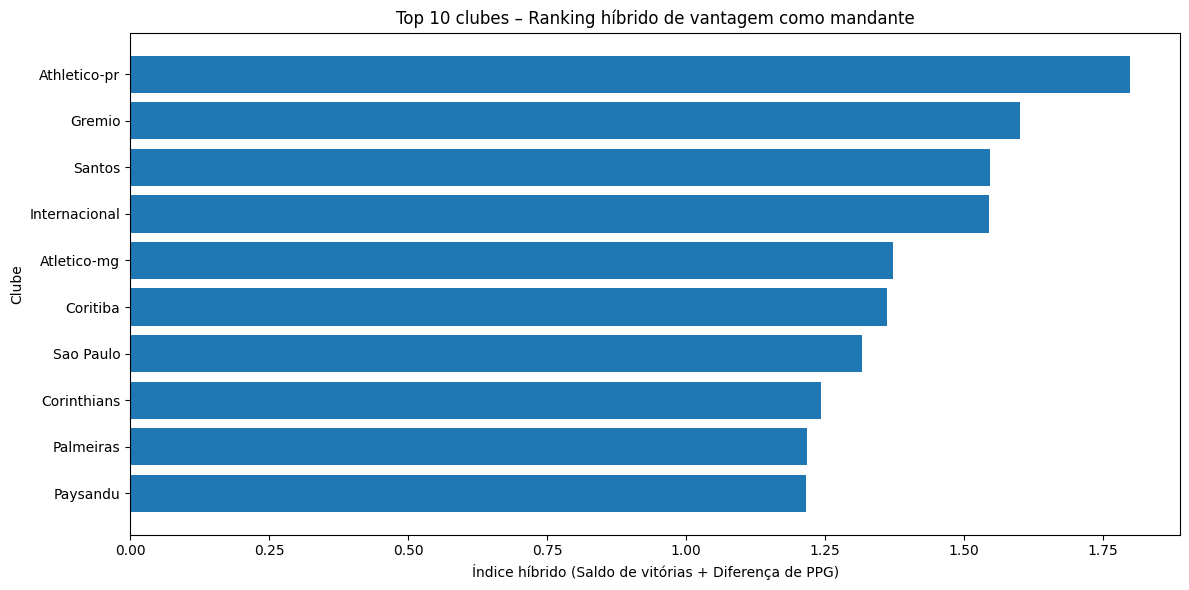

In [0]:
# =========================================================
# GRÁFICO 2 — Ranking híbrido (Saldo + Diferença de PPG)
# Normalização simples para combinação das métricas
# =========================================================

pdf_hibrido = df_resultado.toPandas()

# Normalização (min-max)
pdf_hibrido["saldo_norm"] = (
    (pdf_hibrido["saldo_vitorias_mando"] - pdf_hibrido["saldo_vitorias_mando"].min())
    / (pdf_hibrido["saldo_vitorias_mando"].max() - pdf_hibrido["saldo_vitorias_mando"].min())
)

pdf_hibrido["ppg_norm"] = (
    (pdf_hibrido["vantagem_ppg"] - pdf_hibrido["vantagem_ppg"].min())
    / (pdf_hibrido["vantagem_ppg"].max() - pdf_hibrido["vantagem_ppg"].min())
)

# Índice híbrido (peso igual)
pdf_hibrido["indice_hibrido"] = (
    pdf_hibrido["saldo_norm"] + pdf_hibrido["ppg_norm"]
)

pdf_hibrido = pdf_hibrido.sort_values("indice_hibrido", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(
    pdf_hibrido["clube"],
    pdf_hibrido["indice_hibrido"]
)
plt.xlabel("Índice híbrido (Saldo de vitórias + Diferença de PPG)")
plt.ylabel("Clube")
plt.title("Top 10 clubes – Ranking híbrido de vantagem como mandante")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
